UMAP code snippets. First segment allows for an individual UMAP of a single expression tsv file. Can be used for the summed and max lasc or clavata expresison files. Second segment allows for the comparison of two expression files, though it is too limited to allow one to directly check and uncheck visibility.

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.8/88.8 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.9/56.9 kB 4.5 MB/s eta 0:00:00


/usr/local/lib/python3.10/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
<ipython-input-1-ba4a8e7fb46a>:26: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(data=umap_df, x='UMAP1', y='UMAP2', palette='viridis', s=100, alpha=0.7)


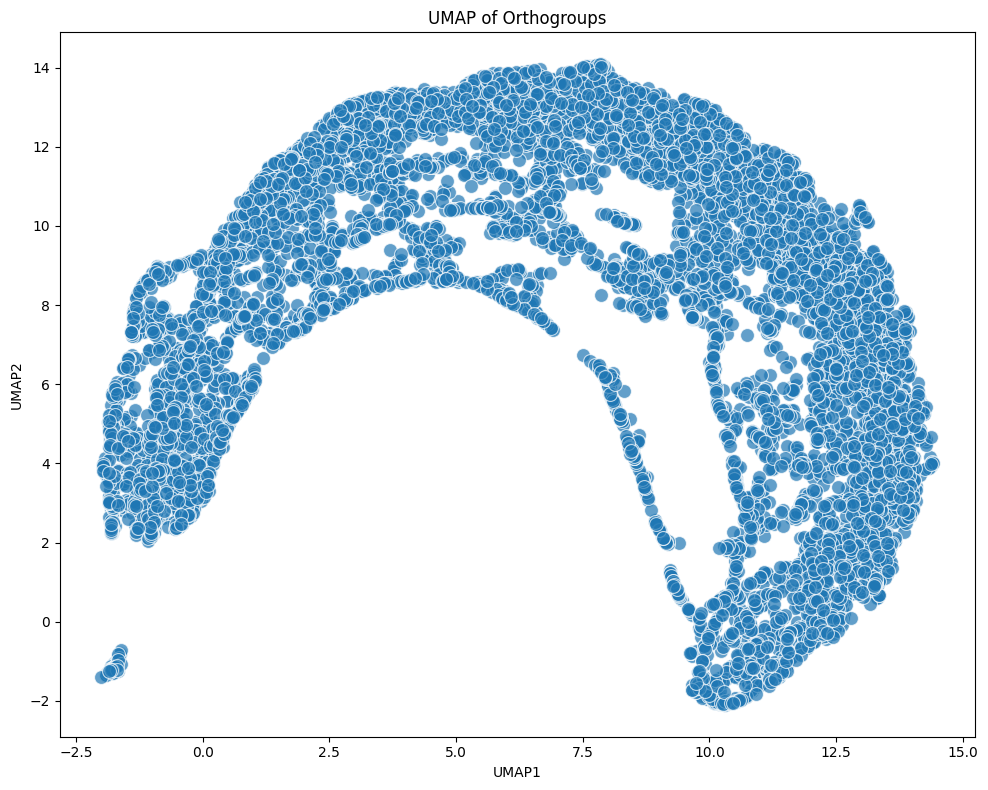

In [ ]:
!pip install umap-learn
import pandas as pd
import umap.umap_ as umap
import matplotlib.pyplot as plt
import seaborn as sns

# Load the TSV file
# File path determines what is being analyzed
file_path = '/content/drive/MyDrive/expression/summed_lasc.expression.txt'
data = pd.read_csv(file_path, sep='\t')

# Extract orthogroup names and tissues data
orthogroups = data.iloc[:, 0]  # Orthogroup names
tissues_data = data.iloc[:, 1:]  # Tissues

# UMAP
reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, random_state=42)
umap_results = reducer.fit_transform(tissues_data)

# Visualization dataframe
umap_df = pd.DataFrame(umap_results, columns=['UMAP1', 'UMAP2'])
umap_df['Orthogroup'] = orthogroups

# Plot the UMAP results
plt.figure(figsize=(10, 8))
sns.scatterplot(data=umap_df, x='UMAP1', y='UMAP2', palette='viridis', s=100, alpha=0.7)
plt.title('UMAP of Orthogroups')
plt.xlabel('UMAP1')
plt.ylabel('UMAP2')
plt.tight_layout()
plt.show()

/usr/local/lib/python3.10/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


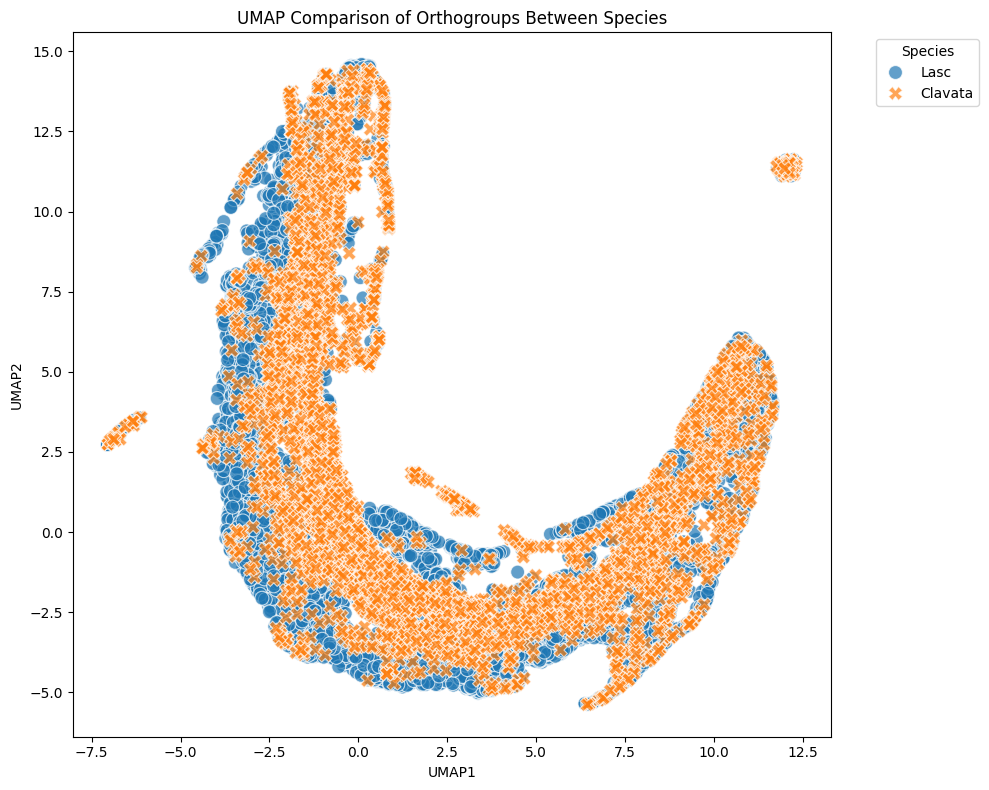

In [ ]:
# Combined UMAP of Clavata and Clavipes

import pandas as pd
import umap.umap_ as umap
import matplotlib.pyplot as plt
import seaborn as sns

# Load TSV files
# file paths determine which two expression files are compared
species1_file = '/content/drive/MyDrive/expression/summed_lasc.expression.txt'
species2_file = '/content/drive/MyDrive/expression/summed_clavata_expression.txt'

data1 = pd.read_csv(species1_file, sep='\t')
data2 = pd.read_csv(species2_file, sep='\t')

# Names the files after their species, change name here if others are used
data1['Species'] = 'Lasc'
data2['Species'] = 'Clavata'

# Ensure tissue columns align
common_tissues = list(set(data1.columns[1:-1]) & set(data2.columns[1:-1]))
data1 = data1[['Species'] + ['Orthogroup'] + common_tissues]
data2 = data2[['Species'] + ['Orthogroup'] + common_tissues]

# Combine datasets
combined_data = pd.concat([data1, data2], ignore_index=True)

# Extract relevant columns for UMAP
orthogroups = combined_data['Orthogroup']
species_labels = combined_data['Species']
tissues_data = combined_data.iloc[:, 2:]

# Replace missing values with zeros
tissues_data.fillna(0, inplace=True)

# Perform UMAP
reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, random_state=42)
umap_results = reducer.fit_transform(tissues_data)

# Create a DataFrame for visualization
umap_df = pd.DataFrame(umap_results, columns=['UMAP1', 'UMAP2'])
umap_df['Species'] = species_labels
umap_df['Orthogroup'] = orthogroups

# Plot UMAP results
plt.figure(figsize=(10, 8))
sns.scatterplot(data=umap_df, x='UMAP1', y='UMAP2', hue='Species', style='Species', s=100, alpha=0.7)
plt.title('UMAP Comparison of Orthogroups Between Species')
plt.xlabel('UMAP1')
plt.ylabel('UMAP2')
plt.legend(title='Species', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()



Filtering of expression data. One script for summed and another for max expression tsv files. It takes the logarithm of all expressions, sums together
the total expression for each orthogroup (all tissues summed), and plots the expression value against the # of orthogroups with the value. A treshold can then be selected which removes all orthogroups under that expression treshold and saves the file.

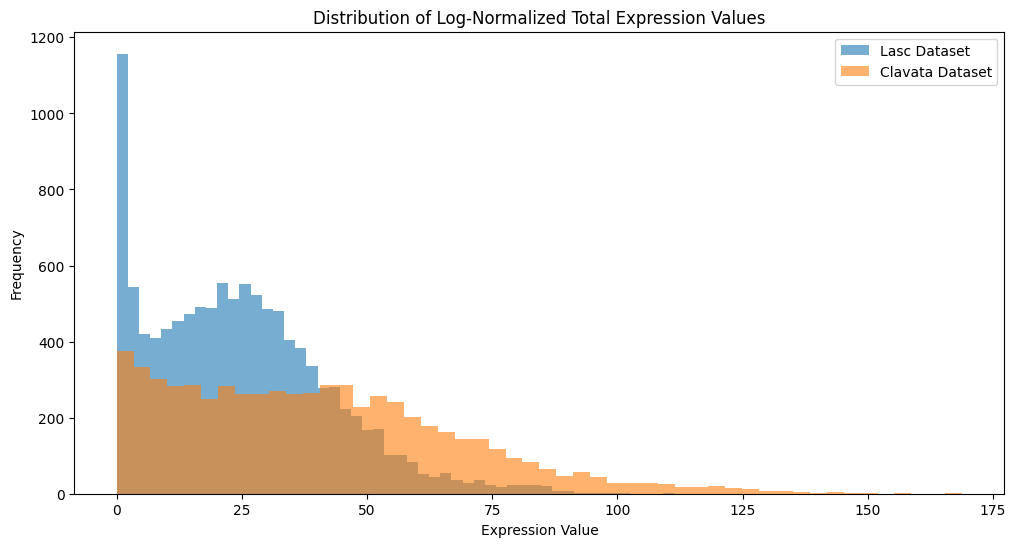

In [ ]:
# Summed expression filtering

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Files, need to be two, lasc and clavata tsv.
file1_path = '/content/drive/MyDrive/expression/summed_lasc.expression.txt'
file2_path = '/content/drive/MyDrive/expression/summed_clavata_expression.txt'

lasc_df = pd.read_csv(file1_path, sep="\t")
clavata_df = pd.read_csv(file2_path, sep="\t")

# Log1p normalization
log_lasc_df = lasc_df.copy()
log_clavata_df = clavata_df.copy()
log_lasc_df.iloc[:, 1:] = np.log1p(lasc_df.iloc[:, 1:])
log_clavata_df.iloc[:, 1:] = np.log1p(clavata_df.iloc[:, 1:])

# Sums together all tissues for each orthogroup
log_lasc_df['Total_Expression'] = log_lasc_df.iloc[:, 1:].sum(axis=1)
log_clavata_df['Total_Expression'] = log_clavata_df.iloc[:, 1:].sum(axis=1)

# Plot
plt.figure(figsize=(12, 6))
plt.hist(log_lasc_df['Total_Expression'], bins=50, alpha=0.6, label="Lasc Dataset")
plt.hist(log_clavata_df['Total_Expression'], bins=50, alpha=0.6, label="Clavata Dataset")
plt.title("Distribution of Log-Normalized Total Expression Values")
plt.xlabel("Expression Value")
plt.ylabel("Frequency")
plt.legend()
plt.show()

# Function for filtering
def filter_orthogroups(original_df, log_df, threshold):
    filtered_indices = log_df['Total_Expression'] >= threshold
    return original_df[filtered_indices].copy()

# FILTER HERE
# Filter orthogroups with total log1p-normalized expression >= treshold
filtered_lasc_df = filter_orthogroups(lasc_df, log_lasc_df, 10)
filtered_clavata_df = filter_orthogroups(clavata_df, log_clavata_df, 15)

# Save filtered original datasets to new files
filtered_lasc_df.to_csv("/content/drive/MyDrive/expression/filtered_summed_lasc.expression.txt", sep="\t", index=False)
filtered_clavata_df.to_csv("/content/drive/MyDrive/expression/filtered_summed_clavata_expression.txt", sep="\t", index=False)


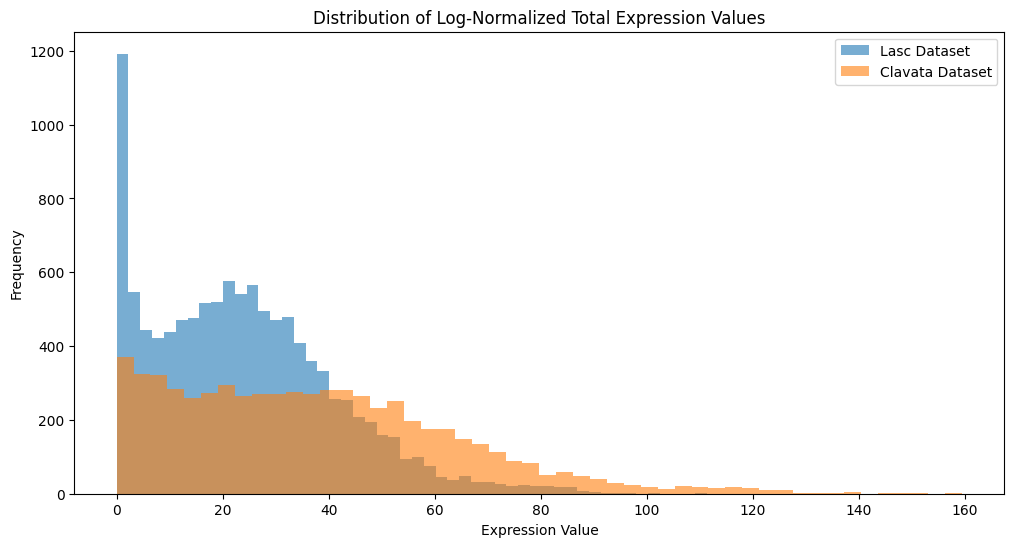

In [ ]:
# Max expression filtering

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Paths to the files
file1_path = '/content/drive/MyDrive/expression/max_lasc.expression.txt'
file2_path = '/content/drive/MyDrive/expression/max_clavata_expression.txt'

lasc_df = pd.read_csv(file1_path, sep="\t")
clavata_df = pd.read_csv(file2_path, sep="\t")

# Log1p normalization
log_lasc_df = lasc_df.copy()
log_clavata_df = clavata_df.copy()
log_lasc_df.iloc[:, 1:] = np.log1p(lasc_df.iloc[:, 1:])
log_clavata_df.iloc[:, 1:] = np.log1p(clavata_df.iloc[:, 1:])

# Sums together all tissues for each orthogroup
log_lasc_df['Total_Expression'] = log_lasc_df.iloc[:, 1:].sum(axis=1)
log_clavata_df['Total_Expression'] = log_clavata_df.iloc[:, 1:].sum(axis=1)

# Plot
plt.figure(figsize=(12, 6))
plt.hist(log_lasc_df['Total_Expression'], bins=50, alpha=0.6, label="Lasc Dataset")
plt.hist(log_clavata_df['Total_Expression'], bins=50, alpha=0.6, label="Clavata Dataset")
plt.title("Distribution of Log-Normalized Total Expression Values")
plt.xlabel("Expression Value")
plt.ylabel("Frequency")
plt.legend()
plt.show()

# Function for filtering
def filter_orthogroups(original_df, log_df, threshold):
    filtered_indices = log_df['Total_Expression'] >= threshold
    return original_df[filtered_indices].copy()

# FILTER HERE
# Filter orthogroups with total log1p-normalized expression >= treshold
filtered_lasc_df = filter_orthogroups(lasc_df, log_lasc_df, 10)
filtered_clavata_df = filter_orthogroups(clavata_df, log_clavata_df, 15)

# Save filtered original datasets to new files
filtered_lasc_df.to_csv("/content/drive/MyDrive/expression/filtered_max_lasc.expression.txt", sep="\t", index=False)
filtered_clavata_df.to_csv("/content/drive/MyDrive/expression/filtered_max_clavata_expression.txt", sep="\t", index=False)

--------------------------------

Pearson, log-pearson and spearman correlation portion. This is the part for the preliminary analyses, boxplots and csv tables come later.

In [8]:
# Correlation on summed data, base stuff
# This takes the summed expression files for both species and
# subsets the data so that only shared OG and tissues are present.
# df_shared and df_shared_log, are the datasets.

import pandas as pd
from scipy.stats import pearsonr
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import spearmanr
from scipy.stats import zscore

# Load files
file1 = '/content/drive/MyDrive/expression/filtered_summed_lasc.expression.txt'
file2 = '/content/drive/MyDrive/expression/filtered_summed_clavata_expression.txt'

df1 = pd.read_csv(file1, sep="\t", index_col=0)
df2 = pd.read_csv(file2, sep="\t", index_col=0)

# Find shared orthogroups and tissues
shared_orthogroups = df1.index.intersection(df2.index)
shared_tissues = df1.columns.intersection(df2.columns)

# Subset the data to include only shared orthogroups and tissues
df1_shared = df1.loc[shared_orthogroups, shared_tissues]
df2_shared = df2.loc[shared_orthogroups, shared_tissues]
df1_shared_log = np.log1p(df1_shared)  # Log-transform
df2_shared_log = np.log1p(df2_shared)  # Log-transform



In [ ]:
# NOTE! the output variables have the same name as the previous snippet,
# use only one of summed or max.
# Correlation on max data, base stuff
# This takes the max expression files for both species and
# subsets the data so that only shared OG and tissues are present.
# df_shared and df_shared_log, are the datasets.


import pandas as pd
from scipy.stats import pearsonr
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import spearmanr
from scipy.stats import zscore

# Load the TSV files
file1 = '/content/drive/MyDrive/expression/max_lasc.expression.txt'
file2 = '/content/drive/MyDrive/expression/max_clavata_expression.txt'

df1 = pd.read_csv(file1, sep="\t", index_col=0)  # Load and set orthogroups as index
df2 = pd.read_csv(file2, sep="\t", index_col=0)

# Find shared orthogroups and tissues
shared_orthogroups = df1.index.intersection(df2.index)
shared_tissues = df1.columns.intersection(df2.columns)

# Subset the data to include only shared orthogroups and tissues
df1_shared = df1.loc[shared_orthogroups, shared_tissues]
df2_shared = df2.loc[shared_orthogroups, shared_tissues]
df1_shared_log = np.log1p(df1_shared)  # Log-transform
df2_shared_log = np.log1p(df2_shared)  # Log-transform


In [13]:
# This is the same as the previous two segments, except it focuses on a single
# tissue comparison. You can look at the variable "shared_tissues", to find
# names for a tissue, and then it will only look at the expression in that


tissue = "Major-ampullate-gland"
if tissue not in df1.columns or tissue not in df2.columns:
    raise ValueError(f"Tissue '{tissue}' not found in both files!")

df1_tissue = df1[[tissue]]
df2_tissue = df2[[tissue]]

# Find shared orthogroups
shared_orthogroups = df1_tissue.index.intersection(df2_tissue.index)

# Subset the data to include only shared orthogroups
df1_shared = df1_tissue.loc[shared_orthogroups]
df2_shared = df2_tissue.loc[shared_orthogroups]
df1_shared_log = np.log1p(df1_shared)  # Log-transform
df2_shared_log = np.log1p(df2_shared)  # Log-transform



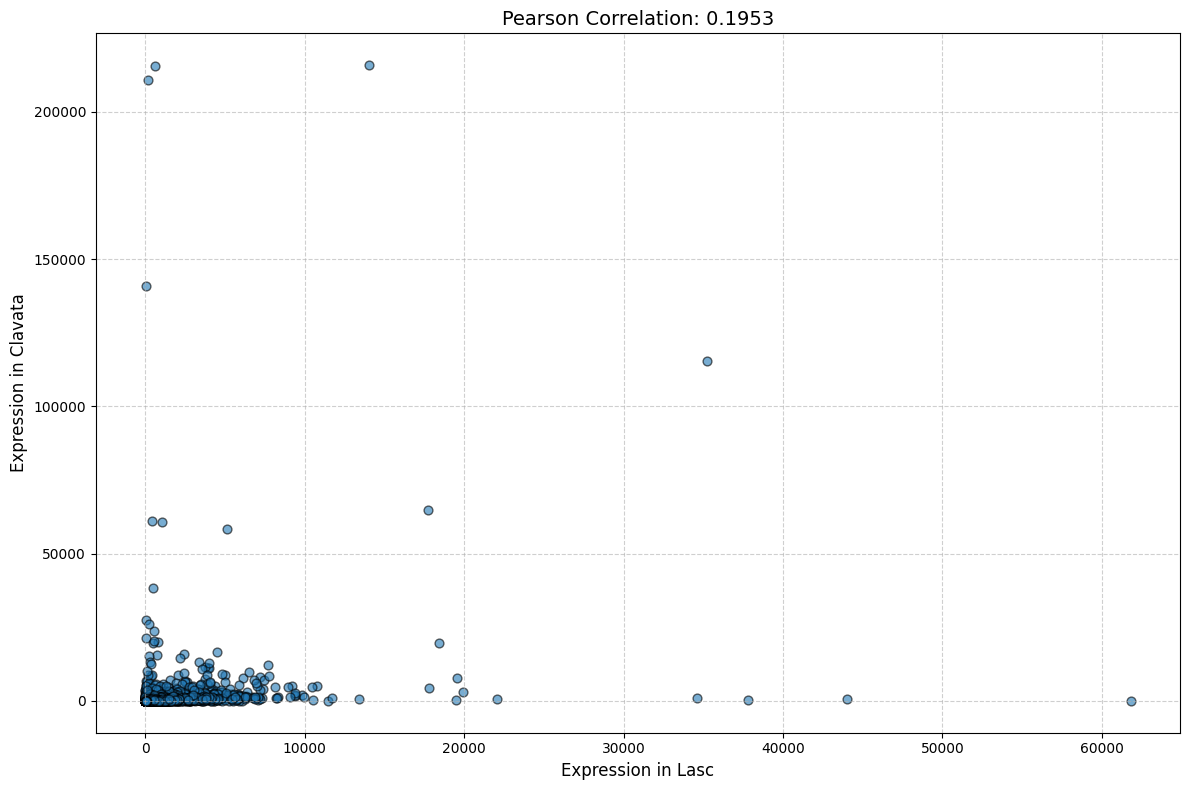

In [ ]:
# Makes a standard pearson correlation plot from df_shared_values

# Flatten the data for correlation calculation
values1 = df1_shared.values.flatten()
values2 = df2_shared.values.flatten()

# Calculate Pearson correlation
correlation, p_value = pearsonr(values1, values2)

# Create the plot
plt.figure(figsize=(12, 8))
plt.scatter(values1, values2, alpha=0.6, edgecolor='k', s=40)
plt.title(f"Pearson Correlation: {correlation:.4f}", fontsize=14)
plt.xlabel("Expression in Lasc", fontsize=12)
plt.ylabel("Expression in Clavata", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()

plt.show()


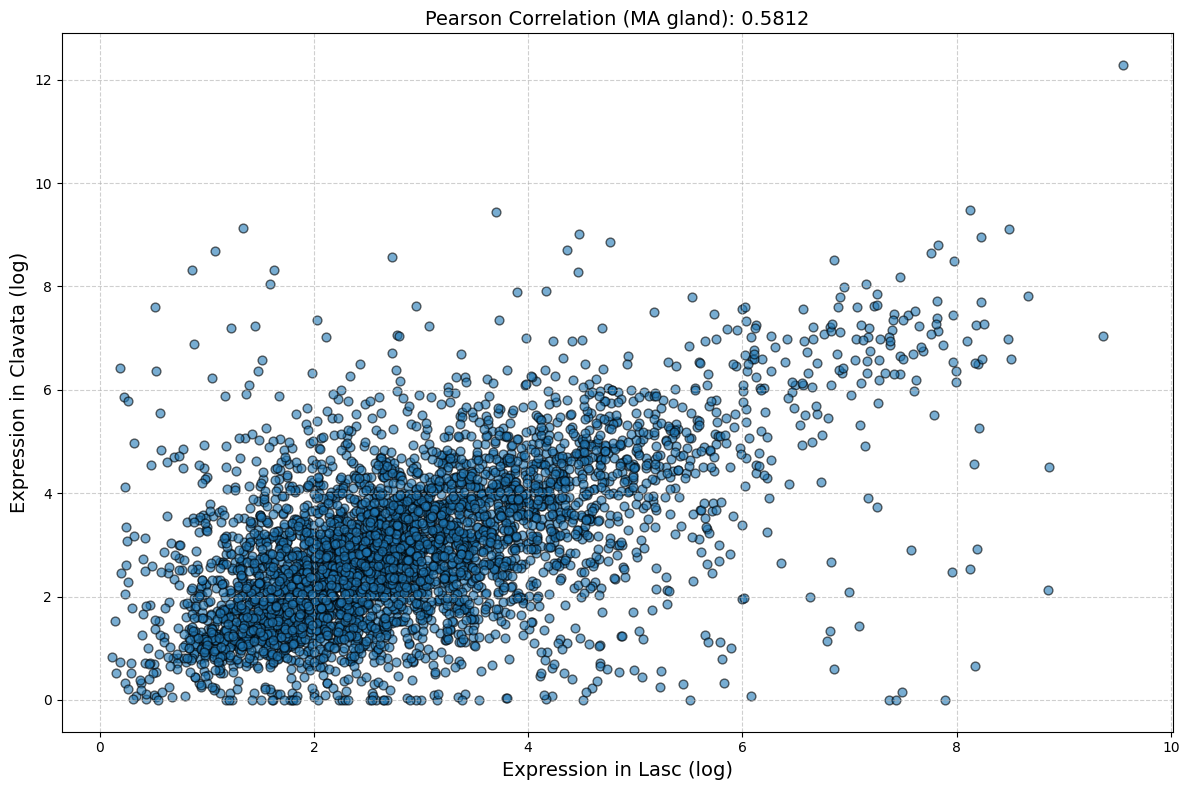

In [15]:
# Log pearson from df_shared_log

# Flatten the data for correlation calculation
values1 = df1_shared_log.values.flatten()
values2 = df2_shared_log.values.flatten()

# Calculate log-Pearson correlation
correlation, p_value = pearsonr(values1, values2)

# Create the plot
plt.figure(figsize=(12, 8))
plt.scatter(values1, values2, alpha=0.6, edgecolor='k', s=40)
plt.title(f"Pearson Correlation (MA gland): {correlation:.4f}", fontsize=14)
plt.xlabel("Expression in Lasc (log)", fontsize=14)
plt.ylabel("Expression in Clavata (log)", fontsize=14)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()

plt.show()


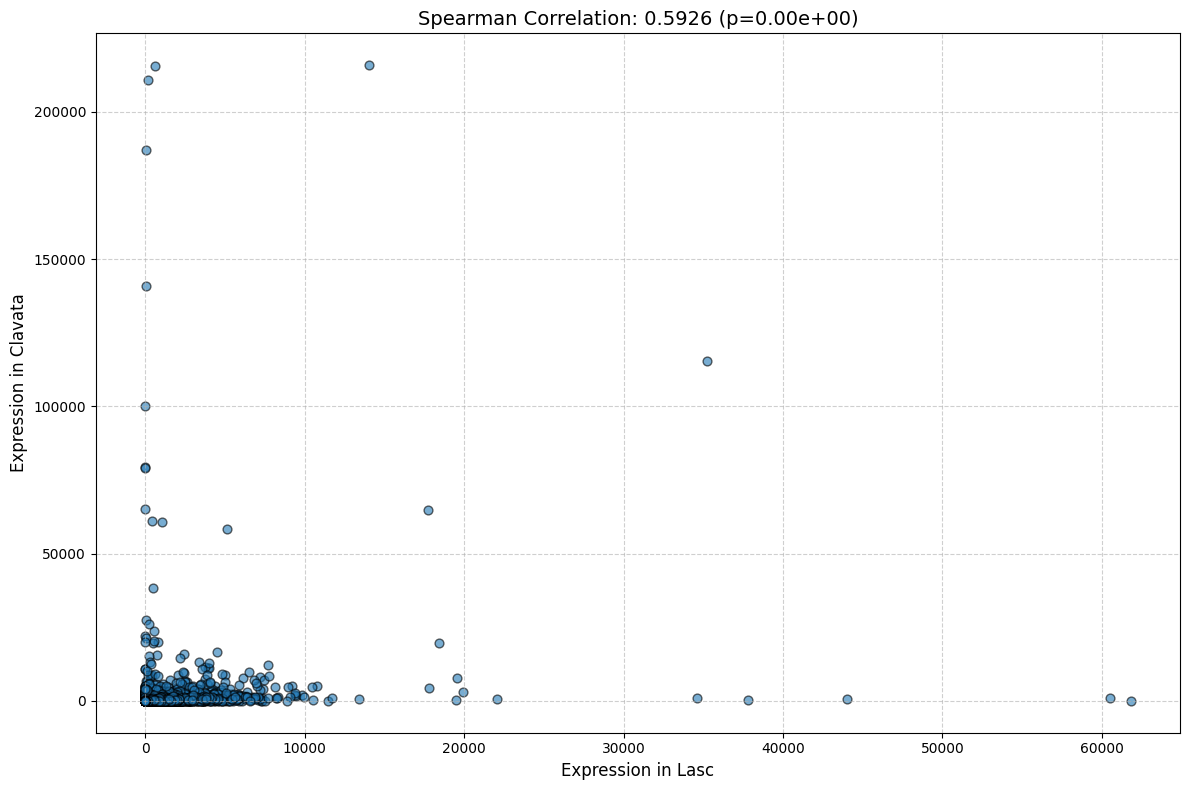

In [ ]:
# Spearman correlation using df_shared_values

# Flatten the data for correlation calculation
values1 = df1_shared.values.flatten()
values2 = df2_shared.values.flatten()

# Calculate Spearman correlation
correlation, p_value = spearmanr(values1, values2)

# Create the scatter plot
plt.figure(figsize=(12, 8))
plt.scatter(values1, values2, alpha=0.6, edgecolor='k', s=40)
plt.title(f"Spearman Correlation: {correlation:.4f} (p={p_value:.2e})", fontsize=14)
plt.xlabel("Expression in Lasc", fontsize=12)
plt.ylabel("Expression in Clavata", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()

plt.show()



In [10]:
# Intra species tissue, input the name of two tissues present in the same
# species to have a log dataset of expression values.
# Note! if you want to change species, do it by changing df1 (lasc) to df2
# in the segment indicated below!

# Select the tissues of interest
tissue1 = "Major-ampullate-gland"
tissue2 = "Minor-ampullate-gland"

if tissue1 not in df1.columns or tissue2 not in df1.columns:
    raise ValueError(f"One or both tissues '{tissue1}' or '{tissue2}' not found in File 1!")

# replace df1 for df2 in the right side of the equation for clavata
# i:e df2[[tissue1]].dropna()
df1_tissue1 = df1[[tissue1]].dropna()
df1_tissue2 = df1[[tissue2]].dropna()

df1_shared_log = np.log1p(df1_tissue1)  # Log-transform
df2_shared_log = np.log1p(df1_tissue2)  # Log-transform

values1 = df1_shared_log[tissue1].values
values2 = df2_shared_log[tissue2].values

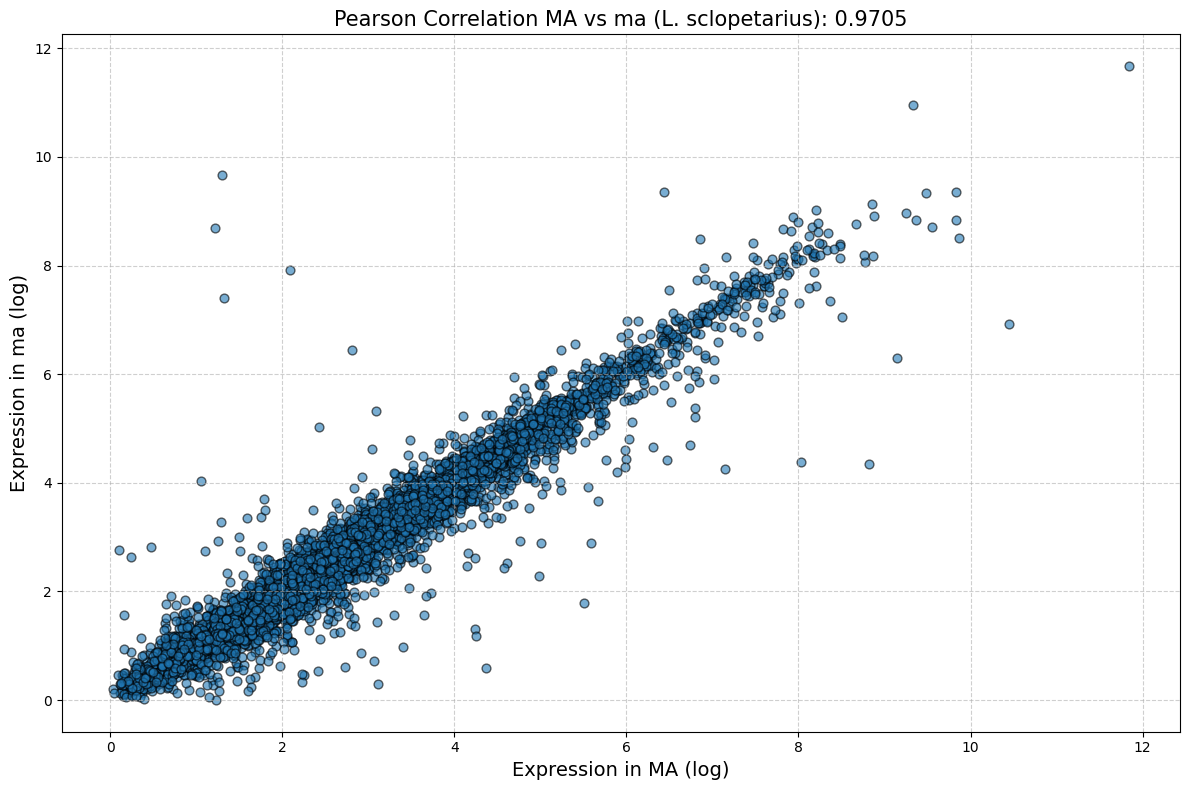

In [12]:
# Calculate log-pearson correlation intra species
# If you want to make one of the previous correlation plots again, rerun their
# previous steps.
correlation, p_value = pearsonr(values1, values2)



# Create the plot
plt.figure(figsize=(12, 8))
plt.scatter(values1, values2, alpha=0.6, edgecolor='k', s=40)
plt.title(f"Pearson Correlation MA vs ma (L. sclopetarius): {correlation:.4f}", fontsize=15)
plt.xlabel("Expression in MA (log)", fontsize=14)
plt.ylabel("Expression in ma (log)", fontsize=14)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()

plt.show()

------------------------------------

The main boxplot segment. This produces a boxplot for the summed dataset, and another for the max dataset. Each boxplot requires two script snippets to make.
The first snippet makes all the possible inter and intra species comparisons using pearson, log-pearson and spearman correlations. It outputs the results into csv table files, one for each comparison type and correlation method, resulting in 12 output files. The second script/snippet takes those files and makes a boxplot out of the results.

In [ ]:
# Summed expression data comparisons

# Compares all tissues internally in each species and also the shared tissues
# Between the two input species.

# You basically only need to feed in the expression data as input file 1 and 2
# It then produces csv tables of comparisons for pearson, spearman and log pearson
# One table per method and species + between species

# It also directly outputs the mean values for each table.


import pandas as pd
import numpy as np
from scipy.stats import pearsonr, spearmanr
import itertools

# Load the TSV files, one for each species
file1 = '/content/drive/MyDrive/expression/filtered_summed_lasc.expression.txt'
file2 = '/content/drive/MyDrive/expression/filtered_summed_clavata_expression.txt'

df1 = pd.read_csv(file1, sep="\t", index_col=0)  # File 1: Species 1
df2 = pd.read_csv(file2, sep="\t", index_col=0)  # File 2: Species 2

### Function to Calculate intra species correlation between all tissues
def calculate_pairwise_correlations(df, methods=["pearson", "log_pearson", "spearman"]):
    tissues = df.columns
    results = {method: pd.DataFrame(index=tissues, columns=tissues) for method in methods}

    for tissue1, tissue2 in itertools.combinations_with_replacement(tissues, 2):
        x = df[tissue1].dropna()
        y = df[tissue2].dropna()
        shared_indices = x.index.intersection(y.index)
        x, y = x[shared_indices], y[shared_indices]

        if "pearson" in methods:
            corr, _ = pearsonr(x, y)
            results["pearson"].loc[tissue1, tissue2] = corr
            results["pearson"].loc[tissue2, tissue1] = corr  # Symmetric

        if "log_pearson" in methods:
            log_x, log_y = np.log1p(x), np.log1p(y)
            corr, _ = pearsonr(log_x, log_y)
            results["log_pearson"].loc[tissue1, tissue2] = corr
            results["log_pearson"].loc[tissue2, tissue1] = corr

        if "spearman" in methods:
            corr, _ = spearmanr(x, y)
            results["spearman"].loc[tissue1, tissue2] = corr
            results["spearman"].loc[tissue2, tissue1] = corr  # Symmetric

    return results

# Perform comparisons for Species 1
within_species1_results = calculate_pairwise_correlations(df1)

# Perform comparisons for Species 2
within_species2_results = calculate_pairwise_correlations(df2)

# Function for inter species tissue comparison, cross_tissue is if we want to
# compare between all shared tissues, like the intra-species function, default
# is to only compare between the same tissue in both species.
def calculate_cross_species_correlations(df1, df2, methods=["pearson", "log_pearson", "spearman"], cross_tissue=False):
    shared_tissues = df1.columns.intersection(df2.columns)

    # Create results storage: For same-tissue or cross-tissue
    if cross_tissue:
        results = {method: pd.DataFrame(index=shared_tissues, columns=shared_tissues) for method in methods}
    else:
        results = {method: pd.Series(index=shared_tissues) for method in methods}

    # Calculate correlations
    if cross_tissue:
        for tissue1, tissue2 in itertools.product(shared_tissues, repeat=2):
            x = df1[tissue1].dropna()
            y = df2[tissue2].dropna()
            shared_indices = x.index.intersection(y.index)
            x, y = x[shared_indices], y[shared_indices]

            if len(x) > 1 and len(y) > 1:  # Ensure valid data
                if "pearson" in methods:
                    corr, _ = pearsonr(x, y)
                    results["pearson"].loc[tissue1, tissue2] = corr

                if "log_pearson" in methods:
                    log_x, log_y = np.log1p(x), np.log1p(y)
                    corr, _ = pearsonr(log_x, log_y)
                    results["log_pearson"].loc[tissue1, tissue2] = corr

                if "spearman" in methods:
                    corr, _ = spearmanr(x, y)
                    results["spearman"].loc[tissue1, tissue2] = corr
    else:
        for tissue in shared_tissues:
            x = df1[tissue].dropna()
            y = df2[tissue].dropna()
            shared_indices = x.index.intersection(y.index)
            x, y = x[shared_indices], y[shared_indices]

            if len(x) > 1 and len(y) > 1:  # Ensure valid data
                if "pearson" in methods:
                    corr, _ = pearsonr(x, y)
                    results["pearson"].loc[tissue] = corr

                if "log_pearson" in methods:
                    log_x, log_y = np.log1p(x), np.log1p(y)
                    corr, _ = pearsonr(log_x, log_y)
                    results["log_pearson"].loc[tissue] = corr

                if "spearman" in methods:
                    corr, _ = spearmanr(x, y)
                    results["spearman"].loc[tissue] = corr

    return results

# Perform same-tissue cross-species comparisons
cross_species_same_results = calculate_cross_species_correlations(df1, df2, cross_tissue=False)

# Perform cross-tissue cross-species comparisons
cross_species_cross_results = calculate_cross_species_correlations(df1, df2, cross_tissue=True)

# Calculate Mean Correlations to output in command line
def calculate_mean_correlations(results_dict):
    mean_correlations = {}
    for method, data in results_dict.items():
        if isinstance(data, pd.DataFrame):  # Matrix
            flattened = data.values.flatten()
            filtered = flattened[flattened != 1]  # Exclude 1s
            mean_value = np.nanmean(filtered)
        elif isinstance(data, pd.Series):  # Series
            filtered = data[data != 1]  # Exclude 1s
            mean_value = filtered.mean()
        mean_correlations[method] = mean_value
    return mean_correlations

# Calculate mean correlations
mean_intra_species1 = calculate_mean_correlations(within_species1_results)
mean_intra_species2 = calculate_mean_correlations(within_species2_results)
mean_cross_same = calculate_mean_correlations(cross_species_same_results)
mean_cross_cross = calculate_mean_correlations(cross_species_cross_results)

# Print Results
print("Mean Intra-Species Correlations (Bridge):", mean_intra_species1)
print("Mean Intra-Species Correlations (Clavata):", mean_intra_species2)
print("Mean Cross-Species Same-Tissue Correlations:", mean_cross_same)
print("Mean Cross-Species Cross-Tissue Correlations:", mean_cross_cross)

# Save Results - important to keep names correct!
# Save intra-species results
for method, matrix in within_species1_results.items():
    matrix.to_csv(f"/content/drive/MyDrive/expression/within_lasc_correlation_{method}.csv")
for method, matrix in within_species2_results.items():
    matrix.to_csv(f"/content/drive/MyDrive/expression/within_clavata_correlation_{method}.csv")

# Save cross-species results
for method, series in cross_species_same_results.items():
    series.to_csv(f"/content/drive/MyDrive/expression/cross_species_correlation_{method}.csv")
for method, matrix in cross_species_cross_results.items():
    matrix.to_csv(f"/content/drive/MyDrive/expression/cross_species_cross_correlation_{method}.csv")


Mean Intra-Species Correlations (Bridge): {'pearson': 0.45146755550610873, 'log_pearson': 0.8180509228135338, 'spearman': 0.8057943139723882}
Mean Intra-Species Correlations (Clavata): {'pearson': 0.16165666312511773, 'log_pearson': 0.71733262409915, 'spearman': 0.7246575945816256}
Mean Cross-Species Same-Tissue Correlations: {'pearson': 0.2606818769210274, 'log_pearson': 0.5379663605424586, 'spearman': 0.5044595442422847}
Mean Cross-Species Cross-Tissue Correlations: {'pearson': 0.1650213174511321, 'log_pearson': 0.5287634023478689, 'spearman': 0.49916493673957774}


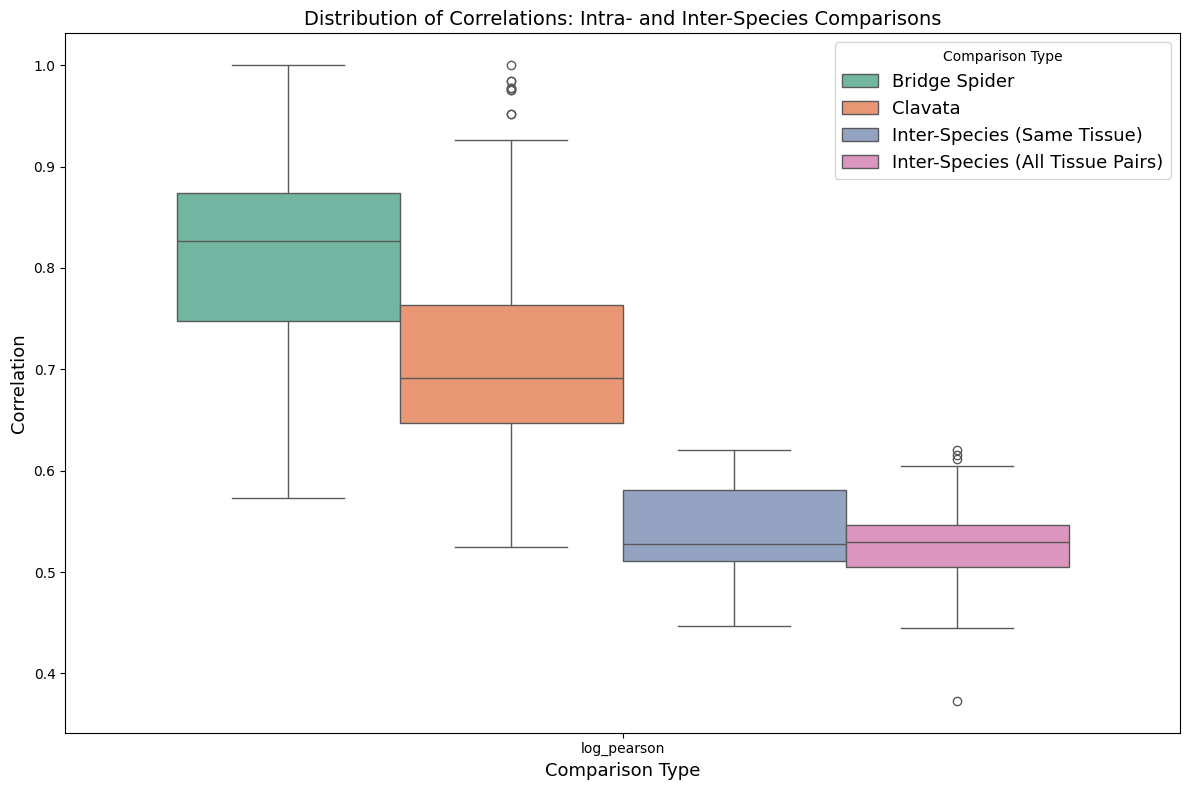

In [3]:
# Boxplots
# Creates a boxplot out of the expression correlation tables.

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr, spearmanr
import itertools

# Load the correlation results
intra_species1_results = {method: pd.read_csv(f"/content/drive/MyDrive/expression/within_lasc_correlation_{method}.csv", index_col=0)
                          for method in ["log_pearson"]}
intra_species2_results = {method: pd.read_csv(f"/content/drive/MyDrive/expression/within_clavata_correlation_{method}.csv", index_col=0)
                          for method in ["log_pearson"]}
inter_species_results = {method: pd.read_csv(f"/content/drive/MyDrive/expression/cross_species_correlation_{method}.csv", index_col=0,)
                         for method in ["log_pearson"]}
cross_tissue_species_results = {method: pd.read_csv(f"/content/drive/MyDrive/expression/cross_species_cross_correlation_{method}.csv", index_col=0)
                                 for method in ["log_pearson"]}

# Prepare data for boxplot
boxplot_data = []

def collect_correlation_values(results_dict, group_label):
    for method, data in results_dict.items():
        if isinstance(data, pd.DataFrame):  # Intra-species: matrix or inter-tissue cross-species
            flattened = data.values.flatten()
        elif isinstance(data, pd.Series):  # Inter-species: series for same-tissue
            flattened = data.values
        filtered = flattened[flattened != 1]  # Exclude correlations of 1
        for value in filtered:
            boxplot_data.append({"Method": method, "Group": group_label, "Correlation": value})

# Collect data for boxplot
collect_correlation_values(intra_species1_results, "Bridge Spider")
collect_correlation_values(intra_species2_results, "Clavata")
collect_correlation_values(inter_species_results, "Inter-Species (Same Tissue)")
collect_correlation_values(cross_tissue_species_results, "Inter-Species (All Tissue Pairs)")

# Create a DataFrame for visualization
boxplot_df = pd.DataFrame(boxplot_data)

# Create the boxplot
plt.figure(figsize=(12, 8))
sns.boxplot(x="Method", y="Correlation", hue="Group", data=boxplot_df, palette="Set2")
plt.title("Distribution of Correlations: Intra- and Inter-Species Comparisons", fontsize=14)
plt.xlabel("Comparison Type", fontsize=13)
plt.ylabel("Correlation", fontsize=13)
plt.legend(title="Comparison Type", fontsize=13)
plt.tight_layout()


plt.show()

In [ ]:
# Max expression data comparisons

# Compares all tissues internally in each species and also the shared tissues
# Between the two input species.

# You basically only need to feed in the expression data as input file 1 and 2
# It then produces csv tables of comparisons for pearson, spearman and log pearson
# One table per method and species + between species

# It also directly outputs the mean values for each table.


import pandas as pd
import numpy as np
from scipy.stats import pearsonr, spearmanr
import itertools

# Load the TSV files, one for each species
file1 = '/content/drive/MyDrive/expression/filtered_max_lasc.expression.txt'
file2 = '/content/drive/MyDrive/expression/filtered_max_clavata_expression.txt'

df1 = pd.read_csv(file1, sep="\t", index_col=0)  # File 1: Species 1
df2 = pd.read_csv(file2, sep="\t", index_col=0)  # File 2: Species 2

### Function to Calculate intra species correlation between all tissues
def calculate_pairwise_correlations(df, methods=["pearson", "log_pearson", "spearman"]):
    tissues = df.columns
    results = {method: pd.DataFrame(index=tissues, columns=tissues) for method in methods}

    for tissue1, tissue2 in itertools.combinations_with_replacement(tissues, 2):
        x = df[tissue1].dropna()
        y = df[tissue2].dropna()
        shared_indices = x.index.intersection(y.index)
        x, y = x[shared_indices], y[shared_indices]

        if "pearson" in methods:
            corr, _ = pearsonr(x, y)
            results["pearson"].loc[tissue1, tissue2] = corr
            results["pearson"].loc[tissue2, tissue1] = corr  # Symmetric

        if "log_pearson" in methods:
            log_x, log_y = np.log1p(x), np.log1p(y)
            corr, _ = pearsonr(log_x, log_y)
            results["log_pearson"].loc[tissue1, tissue2] = corr
            results["log_pearson"].loc[tissue2, tissue1] = corr

        if "spearman" in methods:
            corr, _ = spearmanr(x, y)
            results["spearman"].loc[tissue1, tissue2] = corr
            results["spearman"].loc[tissue2, tissue1] = corr  # Symmetric

    return results

# Perform comparisons for Species 1
within_species1_results = calculate_pairwise_correlations(df1)

# Perform comparisons for Species 2
within_species2_results = calculate_pairwise_correlations(df2)

# Function for inter species tissue comparison, cross_tissue is if we want to
# compare between all shared tissues, like the intra-species function, default
# is to only compare between the same tissue in both species.
def calculate_cross_species_correlations(df1, df2, methods=["pearson", "log_pearson", "spearman"], cross_tissue=False):
    shared_tissues = df1.columns.intersection(df2.columns)

    # Create results storage: For same-tissue or cross-tissue
    if cross_tissue:
        results = {method: pd.DataFrame(index=shared_tissues, columns=shared_tissues) for method in methods}
    else:
        results = {method: pd.Series(index=shared_tissues) for method in methods}

    # Calculate correlations
    if cross_tissue:
        for tissue1, tissue2 in itertools.product(shared_tissues, repeat=2):
            x = df1[tissue1].dropna()
            y = df2[tissue2].dropna()
            shared_indices = x.index.intersection(y.index)
            x, y = x[shared_indices], y[shared_indices]

            if len(x) > 1 and len(y) > 1:  # Ensure valid data
                if "pearson" in methods:
                    corr, _ = pearsonr(x, y)
                    results["pearson"].loc[tissue1, tissue2] = corr

                if "log_pearson" in methods:
                    log_x, log_y = np.log1p(x), np.log1p(y)
                    corr, _ = pearsonr(log_x, log_y)
                    results["log_pearson"].loc[tissue1, tissue2] = corr

                if "spearman" in methods:
                    corr, _ = spearmanr(x, y)
                    results["spearman"].loc[tissue1, tissue2] = corr
    else:
        for tissue in shared_tissues:
            x = df1[tissue].dropna()
            y = df2[tissue].dropna()
            shared_indices = x.index.intersection(y.index)
            x, y = x[shared_indices], y[shared_indices]

            if len(x) > 1 and len(y) > 1:  # Ensure valid data
                if "pearson" in methods:
                    corr, _ = pearsonr(x, y)
                    results["pearson"].loc[tissue] = corr

                if "log_pearson" in methods:
                    log_x, log_y = np.log1p(x), np.log1p(y)
                    corr, _ = pearsonr(log_x, log_y)
                    results["log_pearson"].loc[tissue] = corr

                if "spearman" in methods:
                    corr, _ = spearmanr(x, y)
                    results["spearman"].loc[tissue] = corr

    return results

# Perform same-tissue cross-species comparisons
cross_species_same_results = calculate_cross_species_correlations(df1, df2, cross_tissue=False)

# Perform cross-tissue cross-species comparisons
cross_species_cross_results = calculate_cross_species_correlations(df1, df2, cross_tissue=True)

# Calculate Mean Correlations to output in command line
def calculate_mean_correlations(results_dict):
    mean_correlations = {}
    for method, data in results_dict.items():
        if isinstance(data, pd.DataFrame):  # Matrix
            flattened = data.values.flatten()
            filtered = flattened[flattened != 1]  # Exclude 1s
            mean_value = np.nanmean(filtered)
        elif isinstance(data, pd.Series):  # Series
            filtered = data[data != 1]  # Exclude 1s
            mean_value = filtered.mean()
        mean_correlations[method] = mean_value
    return mean_correlations

# Calculate mean correlations
mean_intra_species1 = calculate_mean_correlations(within_species1_results)
mean_intra_species2 = calculate_mean_correlations(within_species2_results)
mean_cross_same = calculate_mean_correlations(cross_species_same_results)
mean_cross_cross = calculate_mean_correlations(cross_species_cross_results)

# Print Results
print("Mean Intra-Species Correlations (Bridge):", mean_intra_species1)
print("Mean Intra-Species Correlations (Clavata):", mean_intra_species2)
print("Mean Cross-Species Same-Tissue Correlations:", mean_cross_same)
print("Mean Cross-Species Cross-Tissue Correlations:", mean_cross_cross)

# Save Results - important to keep names correct!
# Save intra-species results
for method, matrix in within_species1_results.items():
    matrix.to_csv(f"/content/drive/MyDrive/expression/max_within_lasc_correlation_{method}.csv")
for method, matrix in within_species2_results.items():
    matrix.to_csv(f"/content/drive/MyDrive/expression/max_within_clavata_correlation_{method}.csv")

# Save cross-species results
for method, series in cross_species_same_results.items():
    series.to_csv(f"/content/drive/MyDrive/expression/max_cross_species_correlation_{method}.csv")
for method, matrix in cross_species_cross_results.items():
    matrix.to_csv(f"/content/drive/MyDrive/expression/max_cross_species_cross_correlation_{method}.csv")

Mean Intra-Species Correlations (Bridge): {'pearson': 0.47879483415593543, 'log_pearson': 0.8052107785198483, 'spearman': 0.7967725340104816}
Mean Intra-Species Correlations (Clavata): {'pearson': 0.14996842674161007, 'log_pearson': 0.6810177538951809, 'spearman': 0.6961738234364462}
Mean Cross-Species Same-Tissue Correlations: {'pearson': 0.18485320397311775, 'log_pearson': 0.5477337284798168, 'spearman': 0.5096886820264231}
Mean Cross-Species Cross-Tissue Correlations: {'pearson': 0.13495847514919698, 'log_pearson': 0.5380004672943455, 'spearman': 0.5042625014507525}


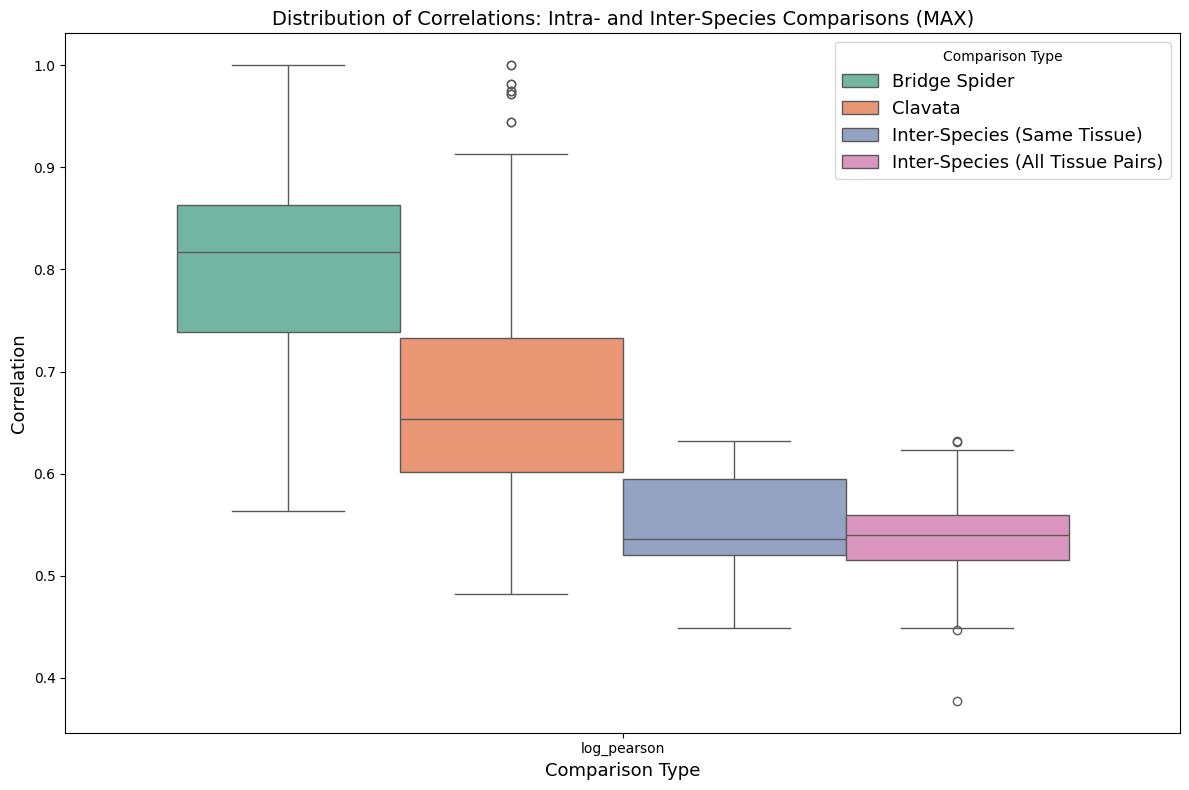

In [2]:
# Boxplots (MAX)
# Creates a boxplot out of the expression correlation tables.

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr, spearmanr
import itertools

# Load the correlation results
intra_species1_results = {method: pd.read_csv(f"/content/drive/MyDrive/expression/max_within_lasc_correlation_{method}.csv", index_col=0)
                          for method in ["log_pearson"]}
intra_species2_results = {method: pd.read_csv(f"/content/drive/MyDrive/expression/max_within_clavata_correlation_{method}.csv", index_col=0)
                          for method in ["log_pearson"]}
inter_species_results = {method: pd.read_csv(f"/content/drive/MyDrive/expression/max_cross_species_correlation_{method}.csv", index_col=0,)
                         for method in ["log_pearson"]}
cross_tissue_species_results = {method: pd.read_csv(f"/content/drive/MyDrive/expression/max_cross_species_cross_correlation_{method}.csv", index_col=0)
                                 for method in ["log_pearson"]}

# Prepare data for boxplot
boxplot_data = []

def collect_correlation_values(results_dict, group_label):
    for method, data in results_dict.items():
        if isinstance(data, pd.DataFrame):  # Intra-species: matrix or inter-tissue cross-species
            flattened = data.values.flatten()
        elif isinstance(data, pd.Series):  # Inter-species: series for same-tissue
            flattened = data.values
        filtered = flattened[flattened != 1]  # Exclude correlations of 1
        for value in filtered:
            boxplot_data.append({"Method": method, "Group": group_label, "Correlation": value})

# Collect data for boxplot
collect_correlation_values(intra_species1_results, "Bridge Spider")
collect_correlation_values(intra_species2_results, "Clavata")
collect_correlation_values(inter_species_results, "Inter-Species (Same Tissue)")
collect_correlation_values(cross_tissue_species_results, "Inter-Species (All Tissue Pairs)")

# Create a DataFrame for visualization
boxplot_df = pd.DataFrame(boxplot_data)

# Create the boxplot
plt.figure(figsize=(12, 8))
sns.boxplot(x="Method", y="Correlation", hue="Group", data=boxplot_df, palette="Set2")

# Customize the plot
plt.title("Distribution of Correlations: Intra- and Inter-Species Comparisons (MAX)", fontsize=14)
plt.xlabel("Comparison Type", fontsize=13)
plt.ylabel("Correlation", fontsize=13)
plt.legend(title="Comparison Type", fontsize=13)
plt.tight_layout()

# Show the plot
plt.show()


Since we want to verify the inherent bias within species, below is a simple principal component analysis that inputs the txt tsv expression files and outputs interactive graphs of the principal components. To change which comparison is made, just go to the plot portion and specify eg: x='PC2', y='PC5'.

In [3]:
# What if ... unless?


import pandas as pd
import numpy as np
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# Load the data
file1 = '/content/drive/MyDrive/expression/filtered_summed_lasc.expression.txt'
file2 = '/content/drive/MyDrive/expression/filtered_summed_clavata_expression.txt'
data1 = pd.read_csv(file1, sep='\t')
data2 = pd.read_csv(file2, sep='\t')

# Add a column to identify the species
data1['Species'] = 'Bridge'
data2['Species'] = 'Clavata'

# Reshape the data to long format for easier merging
long_data1 = pd.melt(data1, id_vars=['Orthogroup', 'Species'], var_name='Tissue', value_name='Expression')
long_data2 = pd.melt(data2, id_vars=['Orthogroup', 'Species'], var_name='Tissue', value_name='Expression')

# Combine the datasets
combined_data = pd.concat([long_data1, long_data2], ignore_index=True)

# Identify shared tissues between species
shared_tissues = set(long_data1['Tissue']).intersection(set(long_data2['Tissue']))

# Filter the data to include only shared tissues
combined_data = combined_data[combined_data['Tissue'].isin(shared_tissues)]

# Pivot to wide format for PCA (Orthogroups as rows, Tissue-Species combinations as columns)
pca_data = combined_data.pivot_table(index='Orthogroup', columns=['Species', 'Tissue'], values='Expression', fill_value=0)

# Standardize the data
scaler = StandardScaler()
scaled_data = scaler.fit_transform(pca_data)

# Perform PCA
pca = PCA(n_components=10)
pca_results = pca.fit_transform(scaled_data)

# Create a DataFrame for PCA results
pca_df = pd.DataFrame(pca_results, columns=['PC1', 'PC2', 'PC3', 'PC4', 'PC5', 'PC6', 'PC7', 'PC8', 'PC9', 'PC10'], index=pca_data.index)

# Add metadata for visualization
pca_df = pca_df.reset_index()
pca_df = pca_df.merge(combined_data[['Orthogroup', 'Species']].drop_duplicates(), on='Orthogroup')

# Plot the PCA results
fig = px.scatter(
    pca_df,
    x='PC1',
    y='PC2',
    color='Species',
    hover_data=['Orthogroup'],
    title='Interactive PCA of Orthogroup Expression',
    labels={'PC1': 'Principal Component 1', 'PC2': 'Principal Component 2'},
    width=800,
    height=600
)

# Show the plot
fig.show()


# Plot the PCA results
fig = px.scatter(
    pca_df,
    x='PC2',
    y='PC4',
    color='Species',
    hover_data=['Orthogroup'],
    title='Interactive PCA of Orthogroup Expression',
    labels={'PC2': 'Principal Component 2', 'PC4': 'Principal Component 4'},
    width=800,
    height=600
)

# Show the plot
fig.show()

In [2]:
print(pca.explained_variance_ratio_)

[0.28752243 0.1216389  0.08731205 0.06974694 0.05885313 0.05593949
 0.05287519 0.05052031 0.04655532 0.04098997]
